In [50]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = pd.read_csv("bank_transactions.csv")

In [52]:
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [53]:
df.isnull().sum()

TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64

In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
df.dtypes

TransactionID               object
CustomerID                  object
CustomerDOB                 object
CustGender                  object
CustLocation                object
CustAccountBalance         float64
TransactionDate             object
TransactionTime              int64
TransactionAmount (INR)    float64
dtype: object

In [59]:
df['CustomerDOB'].fillna(df['CustomerDOB'].mode()[0],inplace=True)

In [60]:
df['CustGender'].fillna(df['CustGender'].mode()[0],inplace=True)

In [61]:
df['CustLocation'].fillna(df['CustLocation'].mode()[0],inplace=True)

In [62]:
df['CustAccountBalance'].fillna(df['CustAccountBalance'].mean())

0           17819.05
1            2270.69
2           17874.44
3          866503.21
4            6714.43
             ...    
1048562      7635.19
1048563     27311.42
1048564    221757.06
1048565     10117.87
1048566     75734.42
Name: CustAccountBalance, Length: 1048567, dtype: float64

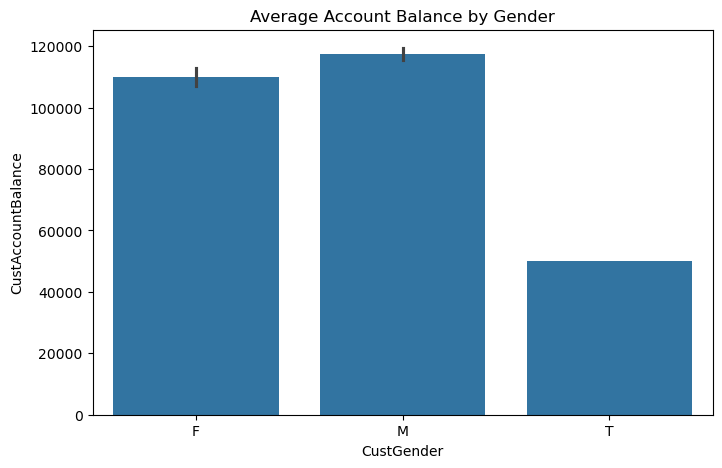

In [63]:
plt.figure(figsize=(8, 5))
sns.barplot(x='CustGender', y='CustAccountBalance', data=df, estimator='mean')
plt.title('Average Account Balance by Gender')
plt.savefig('Gender wise average account balance.png')
plt.show()

Insight: This chart highlights the average financial capacity of male vs. female customers. If one group has a significantly higher balance, the bank can tailor premium savings schemes or investment products specifically for them.

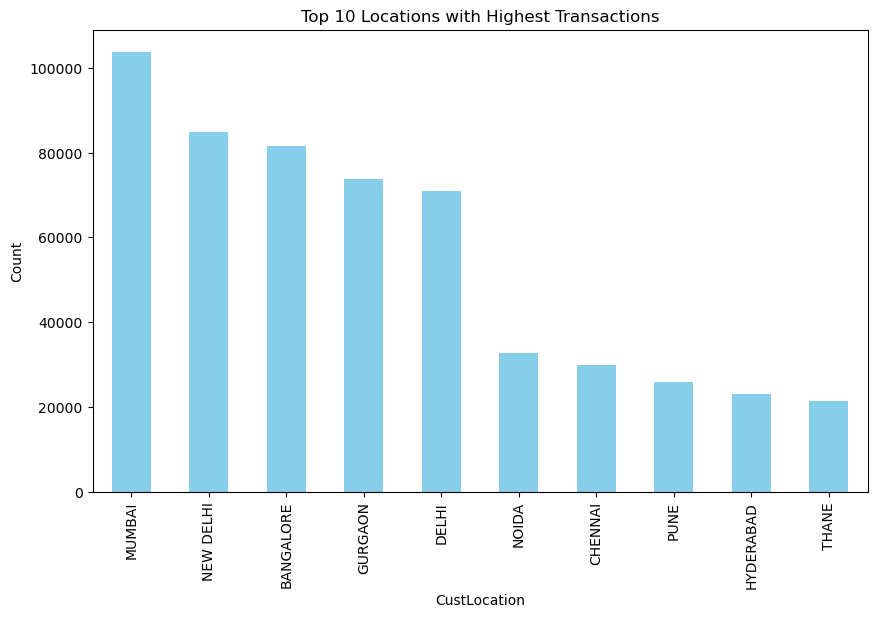

In [64]:
plt.figure(figsize=(10, 6))
df['CustLocation'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Locations with Highest Transactions')
plt.ylabel('Count')
plt.savefig('Top 10 Locations by Transaction Count.png')
plt.show()

Insight: Urban hubs like Mumbai, Delhi, or Bangalore typically show the highest transaction volumes. This data helps the bank decide where to expand ATM networks or physical branches for better accessibility.

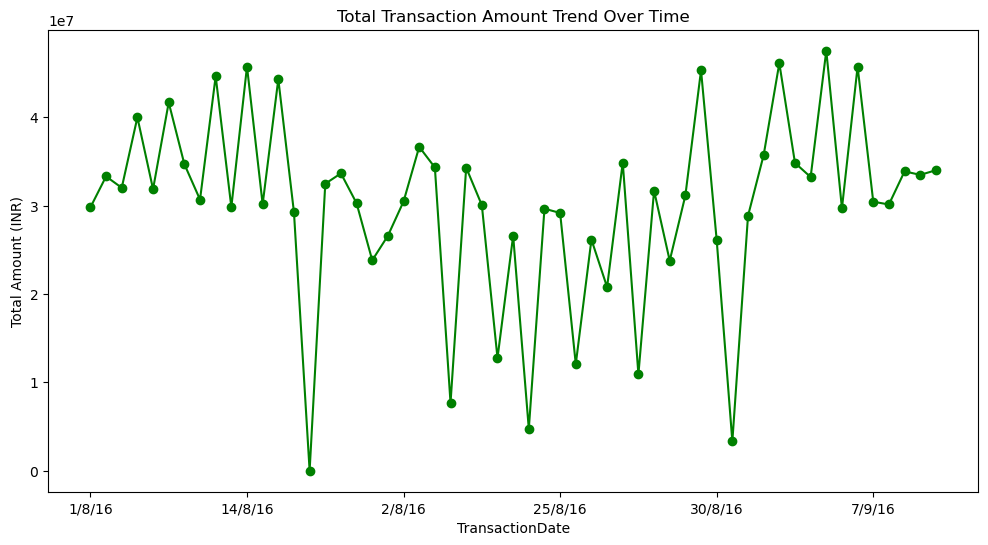

In [65]:
plt.figure(figsize=(12, 6))
df.groupby('TransactionDate')['TransactionAmount (INR)'].sum().plot(marker='o', color='green')
plt.title('Total Transaction Amount Trend Over Time')
plt.ylabel('Total Amount (INR)')
plt.savefig('Transactions over time.png')
plt.show()

Insight: This visualizes the peak days for transactions (e.g., salary days at the start of the month). It helps the bank manage server loads and plan marketing campaigns during high-activity periods.

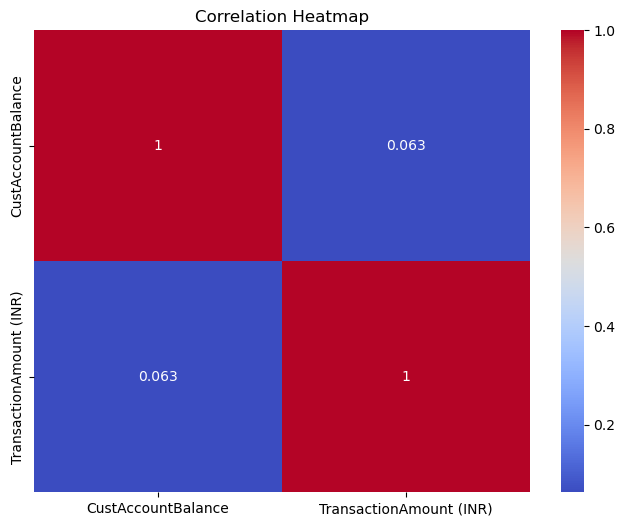

In [66]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['CustAccountBalance', 'TransactionAmount (INR)']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('Correlation between numerical values.png')
plt.show()

Insight: It determines if there is a direct relationship between a customer's account balance and their spending amount. A high correlation suggests that customers with more funds are also making larger purchases.

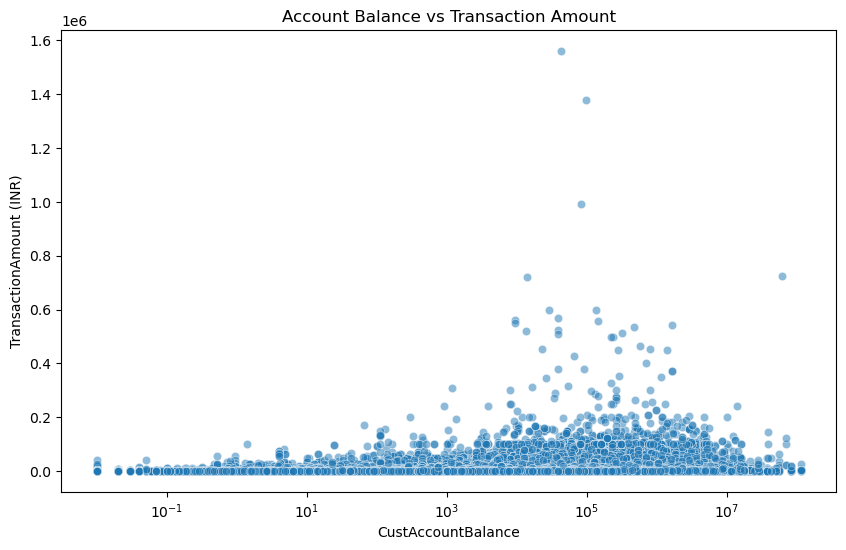

In [67]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CustAccountBalance', y='TransactionAmount (INR)', data=df, alpha=0.5)
plt.xscale('log')
plt.title('Account Balance vs Transaction Amount')
plt.savefig('Account Balance vs Transaction Amount.png')
plt.show()

Insight: This reveals spending habits and helps identify "outliers" (unusually large transactions). It also shows if low-balance customers are making high-value transactions, which could indicate a need for credit or loan products.